In [1]:
!pip install pandas numpy matplotlib seaborn statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 7.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 8.7 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 7.6 MB/s  0:00:01 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 9.6 MB/s  0:00:01m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 14.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 10.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 12.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [seaborn]2/13 [seaborn]ib]]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 130

print("Libraries loaded.")

Libraries loaded.


In [3]:
micro = pd.read_csv("micro_clean.csv")
large = pd.read_csv("large_clean.csv")

print(f"Micro: {micro.shape}  |  Large: {large.shape}")
micro.head(3)

Micro: (1035, 45)  |  Large: (1177, 34)


,video_id,video_title,description,tags,category_id,published_at,channel_id,channel_title,view_count,like_count,...,title_hashtag_count,desc_hashtag_count,is_vlog,is_short,is_daily_life,is_first_video,duration_sec,duration_bucket,category_name,source
0,ZbxxbwKU89c,mt15 ... #viralvideo #terending #mydreambike #...,mt15 ... #viralvideo #terending #mydreambike #...,NaN,22,2026-04-14 11:53:19+00:00,UCk9FIlO0LEuNloLxTERQH4Q,Akash Kumar@,624,8,...,6,8,1,0,0,1,18.0,<=1 min,People & Blogs,micro
1,2ThqSZnSXn4,My First Vlog #youtubeshorts #shorts #villagel...,My First Vlog #youtubeshorts #shorts #villagel...,dasharathprajapativlog96 ||| dasharathprajapat...,22,2026-04-14 11:35:00+00:00,UCQO3oW5YH7jx9KyemPt68Wg,Dasharath Prajapati Vlogs 96,412,5,...,4,4,1,1,0,1,57.0,<=1 min,People & Blogs,micro
2,xJn7zCZeSxU,My first vlog please support #viral vlog 1.2 M...,आज के इस व्लॉग में मैं [जगह का नाम/गतिविधि] की...,NaN,22,2026-04-14 11:12:18+00:00,UC1wqW1cOllIoqgAVMFpJhSA,Ajit Official,58,7,...,1,2,1,0,0,1,10.0,<=1 min,People & Blogs,micro


In [4]:
day_map = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday',
           4:'Friday', 5:'Saturday', 6:'Sunday'}
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

large['post_day'] = large['publish_weekday'].map(day_map)

print("Micro post_day sample:", micro['post_day'].unique()[:3])
print("Large post_day sample:", large['post_day'].unique()[:3])
print("\nAlignment complete.")

Micro post_day sample: <StringArray>
['Tuesday', 'Monday', 'Sunday']
Length: 3, dtype: str
Large post_day sample: <StringArray>
['Thursday', 'Monday', 'Tuesday']
Length: 3, dtype: str

Alignment complete.


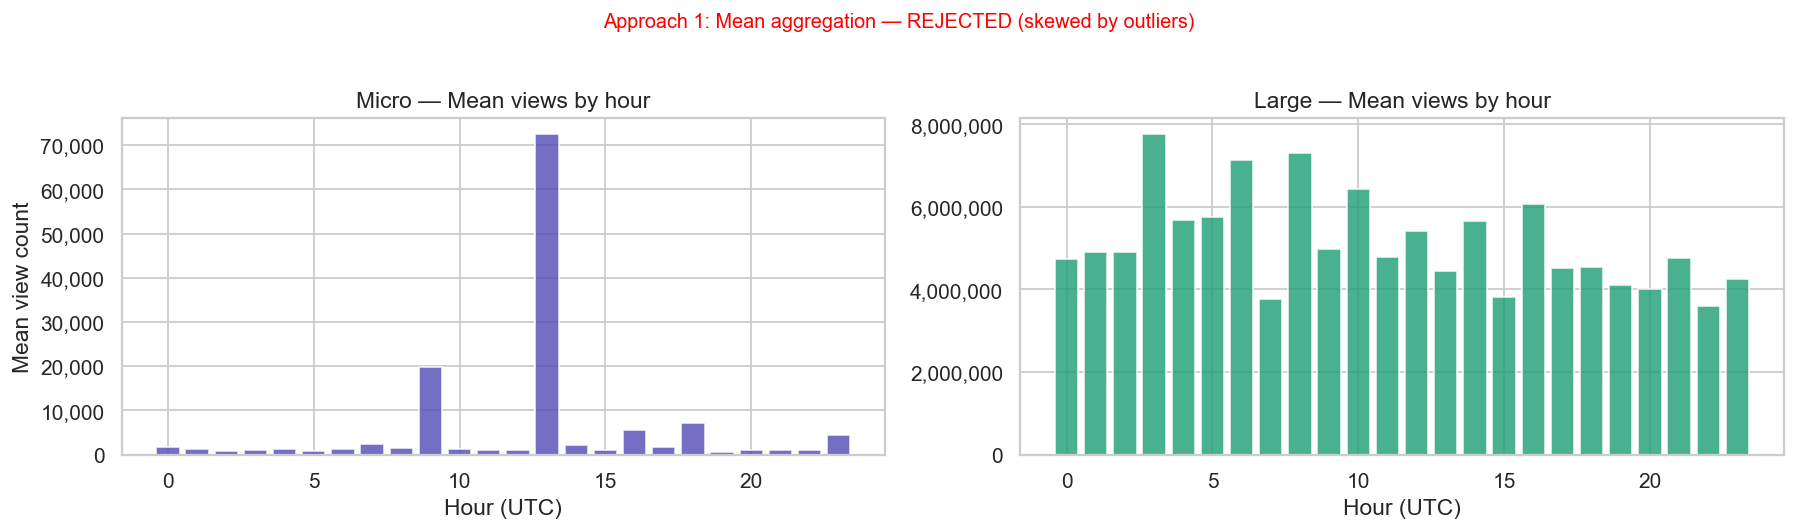

Micro hour 0  — Mean: 1779.0  | Median: 1252.0
→ Mean is inflated by viral videos. Median is more representative.


In [5]:
# --- APPROACH 1: Mean aggregation (rejected due to outlier skew) ---

micro_hour_mean = micro.groupby('publish_hour')['view_count'].mean()
large_hour_mean = large.groupby('publish_hour')['view_count'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(micro_hour_mean.index, micro_hour_mean.values, color='#534AB7', alpha=0.8)
axes[0].set_title("Micro — Mean views by hour")
axes[0].set_xlabel("Hour (UTC)")
axes[0].set_ylabel("Mean view count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(large_hour_mean.index, large_hour_mean.values, color='#1D9E75', alpha=0.8)
axes[1].set_title("Large — Mean views by hour")
axes[1].set_xlabel("Hour (UTC)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle("Approach 1: Mean aggregation — REJECTED (skewed by outliers)",
             fontsize=11, color='red', y=1.02)
plt.tight_layout()
plt.show()

print("Micro hour 0  — Mean:", round(micro_hour_mean[0], 0),
      " | Median:", micro.groupby('publish_hour')['view_count'].median()[0])
print("→ Mean is inflated by viral videos. Median is more representative.")

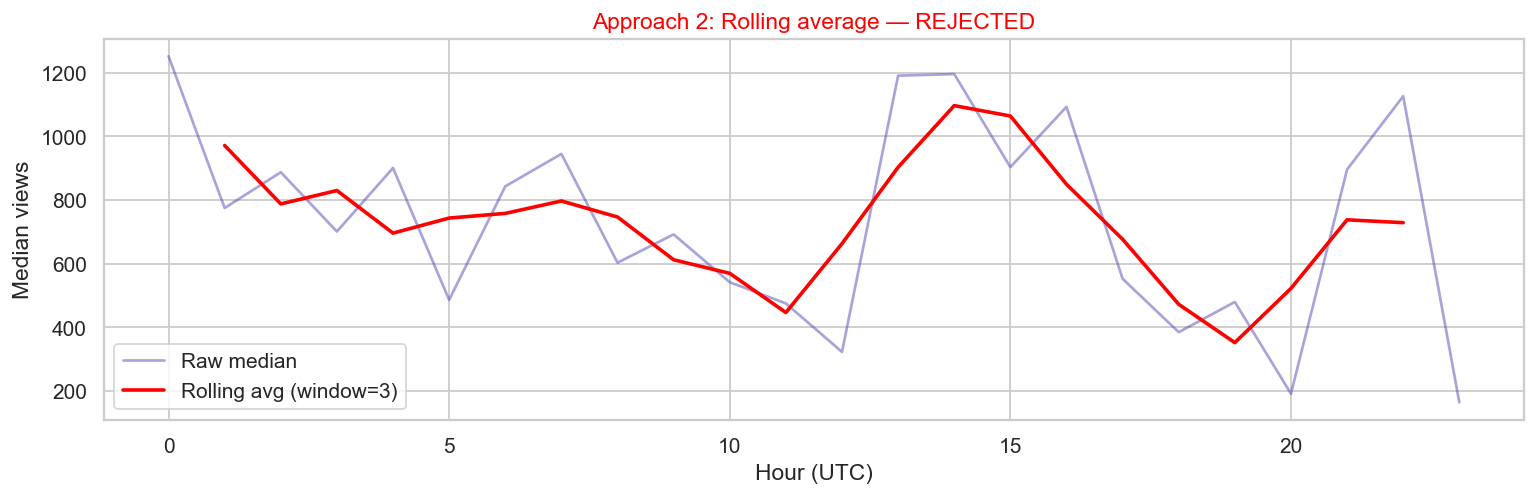

Issue: Data is cross-sectional, not a true time series per channel.
→ ARIMA, STL, seasonal_decompose are all inappropriate here.


In [6]:
# --- APPROACH 2: Rolling average (rejected — not true time series) ---

from statsmodels.tsa.seasonal import seasonal_decompose

micro_hour_median = micro.groupby('publish_hour')['view_count'].median()

rolling_smooth = micro_hour_median.rolling(window=3, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(micro_hour_median.index, micro_hour_median.values,
        label='Raw median', color='#534AB7', alpha=0.5, linewidth=1.5)
ax.plot(rolling_smooth.index, rolling_smooth.values,
        label='Rolling avg (window=3)', color='red', linewidth=2)
ax.set_title("Approach 2: Rolling average — REJECTED", color='red')
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Median views")
ax.legend()
plt.tight_layout()
plt.show()

print("Issue: Data is cross-sectional, not a true time series per channel.")
print("→ ARIMA, STL, seasonal_decompose are all inappropriate here.")

In [7]:
# --- APPROACH 3: Rank by micro performance only (rejected — ignores competition) ---

micro_perf_only = micro.groupby(['post_day', 'publish_hour'])['view_count'].median().reset_index()
micro_perf_only.columns = ['day', 'hour', 'micro_views']
micro_perf_only['rank_only'] = micro_perf_only['micro_views'].rank(pct=True)

top5_naive = micro_perf_only.nlargest(5, 'rank_only')[['day', 'hour', 'micro_views', 'rank_only']]
print("Top 5 slots by micro performance ONLY (no competition filter):")
print(top5_naive.to_string(index=False))

large_density_check = large.groupby(['post_day', 'publish_hour']).size().reset_index()
large_density_check.columns = ['day', 'hour', 'large_count']

merged_check = pd.merge(top5_naive, large_density_check, on=['day','hour'], how='left').fillna(0)
print("\nSame slots WITH large channel competition:")
print(merged_check[['day', 'hour', 'micro_views', 'large_count']].to_string(index=False))
print("\n→ Need to subtract competition density to find truly strategic windows.")

Top 5 slots by micro performance ONLY (no competition filter):
      day  hour  micro_views  rank_only
Wednesday    13    5112341.0   1.000000
   Friday     9     936582.0   0.989796
 Saturday     9     143837.5   0.979592
Wednesday    23      38255.0   0.969388
Wednesday    12      25025.0   0.959184

Same slots WITH large channel competition:
      day  hour  micro_views  large_count
Wednesday    13    5112341.0           11
   Friday     9     936582.0            6
 Saturday     9     143837.5            4
Wednesday    23      38255.0           22
Wednesday    12      25025.0            6

→ Need to subtract competition density to find truly strategic windows.


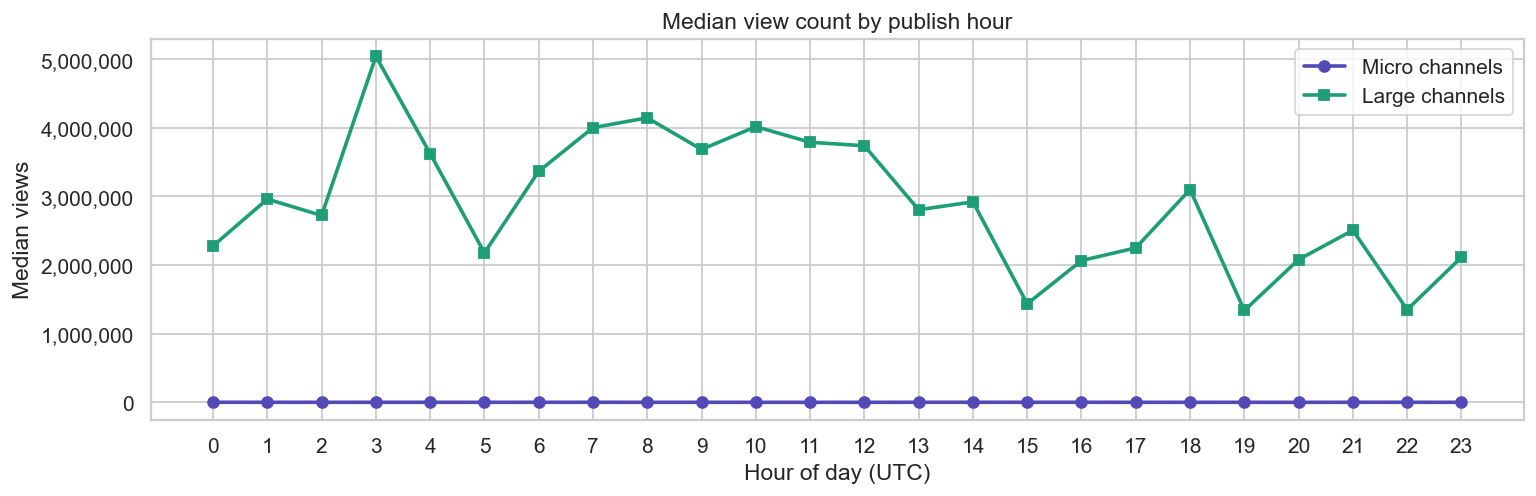

In [8]:
# Median views by hour — micro vs large
micro_hour = micro.groupby('publish_hour')['view_count'].median()
large_hour = large.groupby('publish_hour')['view_count'].median()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(micro_hour.index, micro_hour.values, marker='o',
        label='Micro channels', color='#534AB7', linewidth=2)
ax.plot(large_hour.index, large_hour.values, marker='s',
        label='Large channels', color='#1D9E75', linewidth=2)
ax.set_title("Median view count by publish hour")
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Median views")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

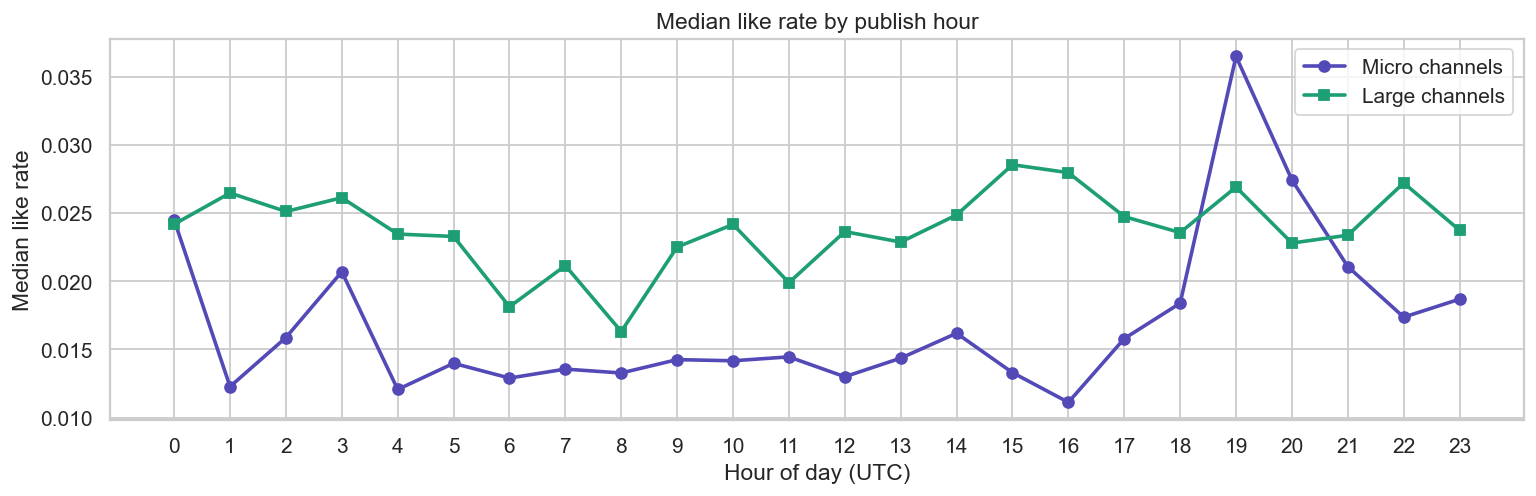

In [9]:
# Median like rate by hour
micro_hr_lr = micro.groupby('publish_hour')['like_rate'].median()
large_hr_lr = large.groupby('publish_hour')['like_rate'].median()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(micro_hr_lr.index, micro_hr_lr.values, marker='o',
        label='Micro channels', color='#534AB7', linewidth=2)
ax.plot(large_hr_lr.index, large_hr_lr.values, marker='s',
        label='Large channels', color='#1D9E75', linewidth=2)
ax.set_title("Median like rate by publish hour")
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Median like rate")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

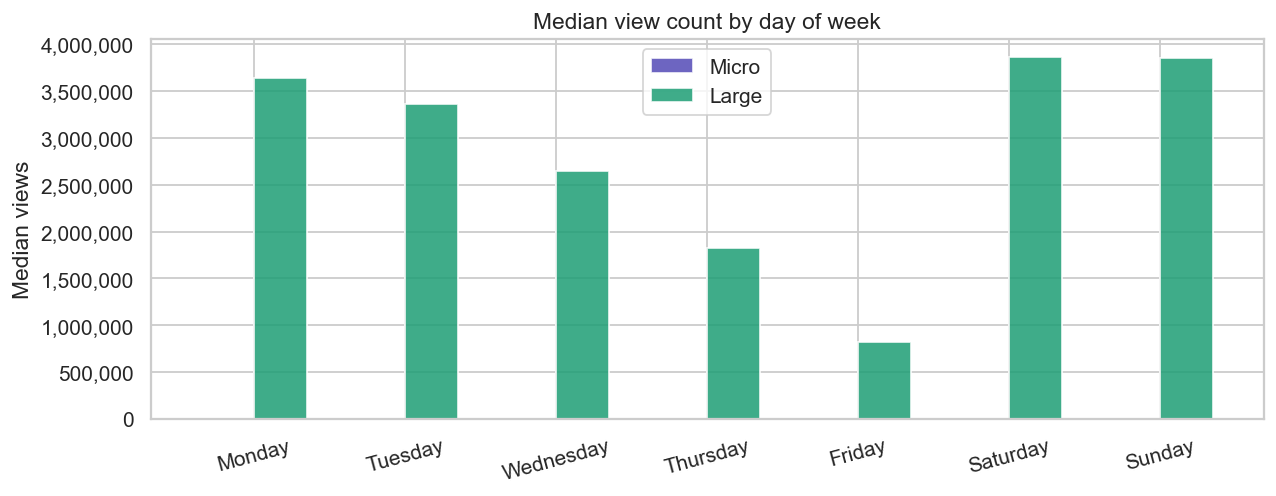

In [10]:
# Median views by day of week
micro_day = micro.groupby('post_day')['view_count'].median().reindex(day_order)
large_day = large.groupby('post_day')['view_count'].median().reindex(day_order)

x = np.arange(len(day_order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, micro_day.values, width, label='Micro', color='#534AB7', alpha=0.85)
ax.bar(x + width/2, large_day.values, width, label='Large', color='#1D9E75', alpha=0.85)
ax.set_title("Median view count by day of week")
ax.set_xticks(x)
ax.set_xticklabels(day_order, rotation=15)
ax.set_ylabel("Median views")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.show()

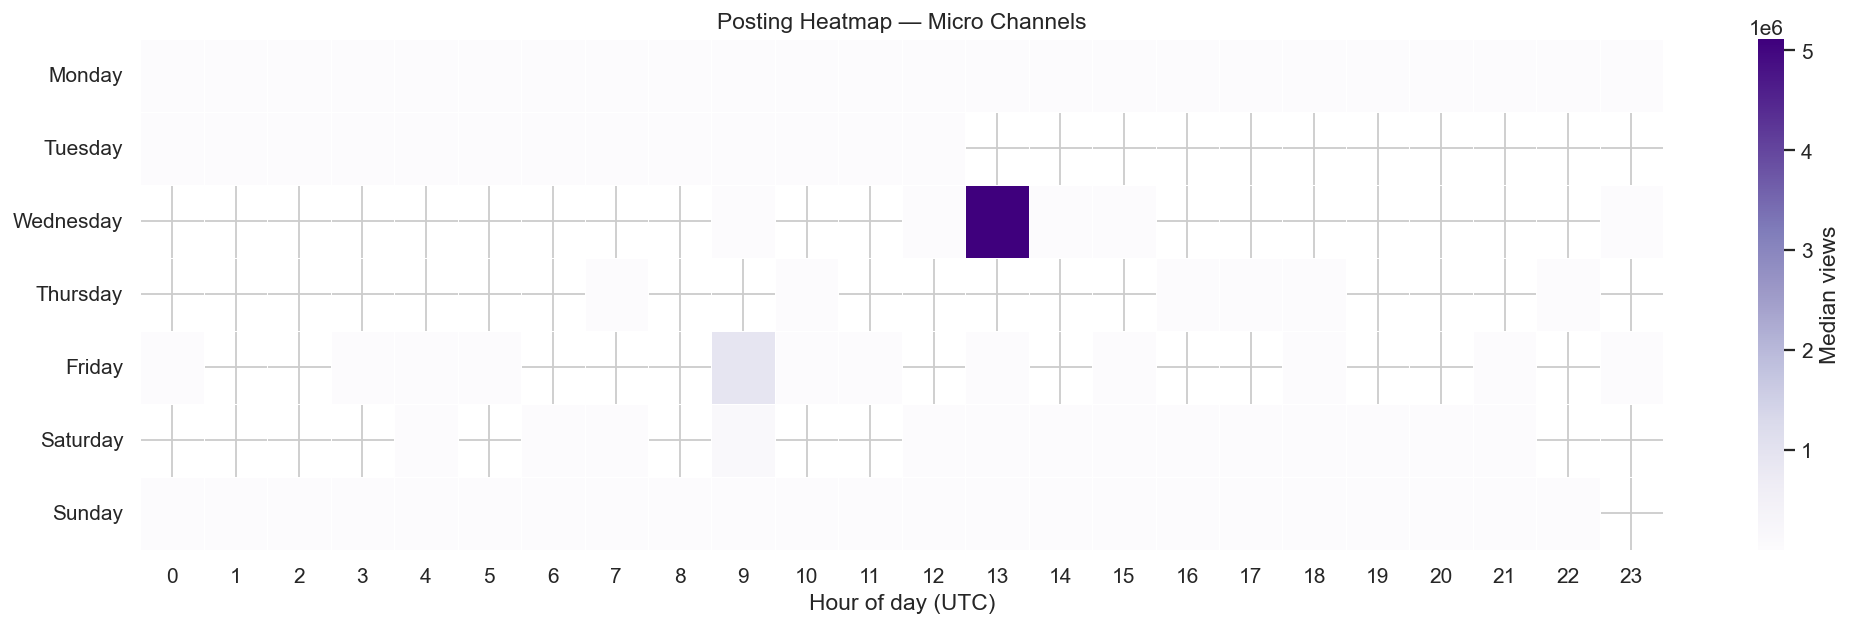

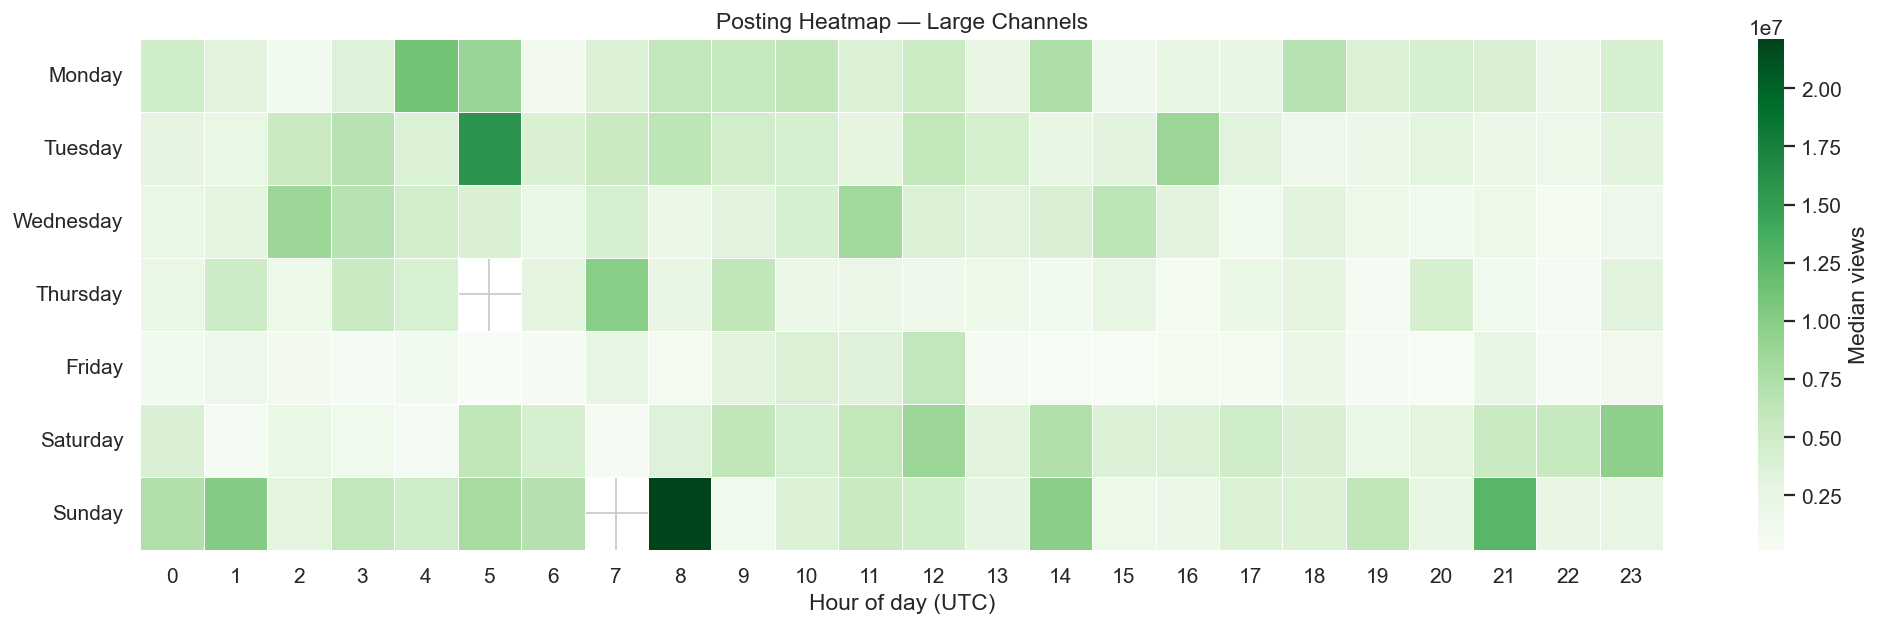

In [11]:
# Heatmaps (day × hour)
def make_heatmap(df, title, cmap='Purples'):
    pivot = (df.pivot_table(values='view_count', index='post_day',
                            columns='publish_hour', aggfunc='median')
               .reindex(day_order)
               .reindex(columns=range(24), fill_value=0))
    fig, ax = plt.subplots(figsize=(16, 5))
    sns.heatmap(pivot, ax=ax, cmap=cmap, linewidths=0.3,
                cbar_kws={'label': 'Median views'})
    ax.set_title(title)
    ax.set_xlabel("Hour of day (UTC)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
    return pivot

micro_pivot = make_heatmap(micro, "Posting Heatmap — Micro Channels", cmap='Purples')
large_pivot = make_heatmap(large, "Posting Heatmap — Large Channels", cmap='Greens')

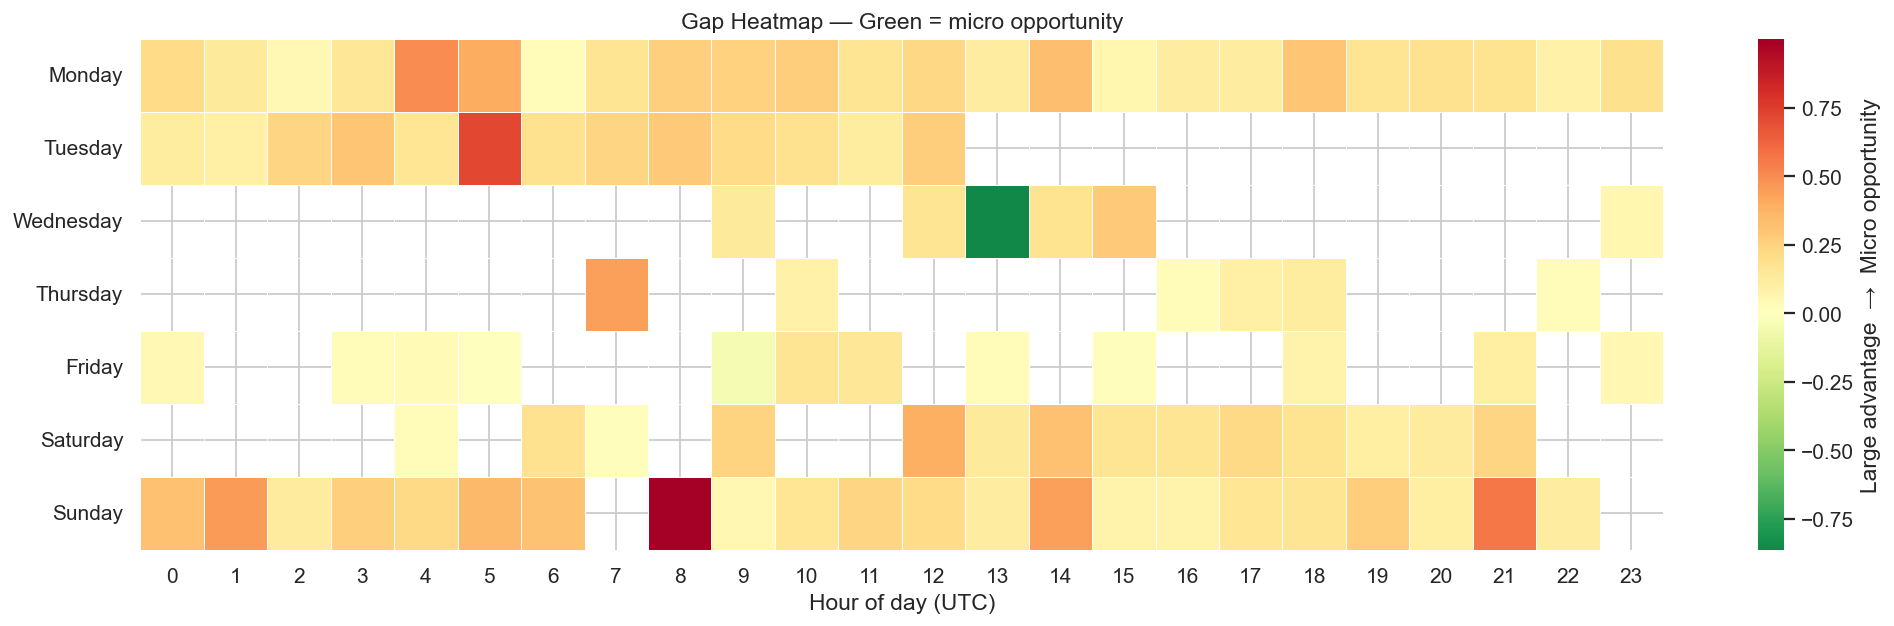

In [12]:
# Gap heatmap: large minus micro (normalized)
def normalize(df):
    return (df - df.min().min()) / (df.max().max() - df.min().min() + 1e-9)

gap = normalize(large_pivot) - normalize(micro_pivot)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(gap, ax=ax, cmap='RdYlGn_r', center=0, linewidths=0.3,
            cbar_kws={'label': 'Large advantage  →  Micro opportunity'})
ax.set_title("Gap Heatmap — Green = micro opportunity")
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

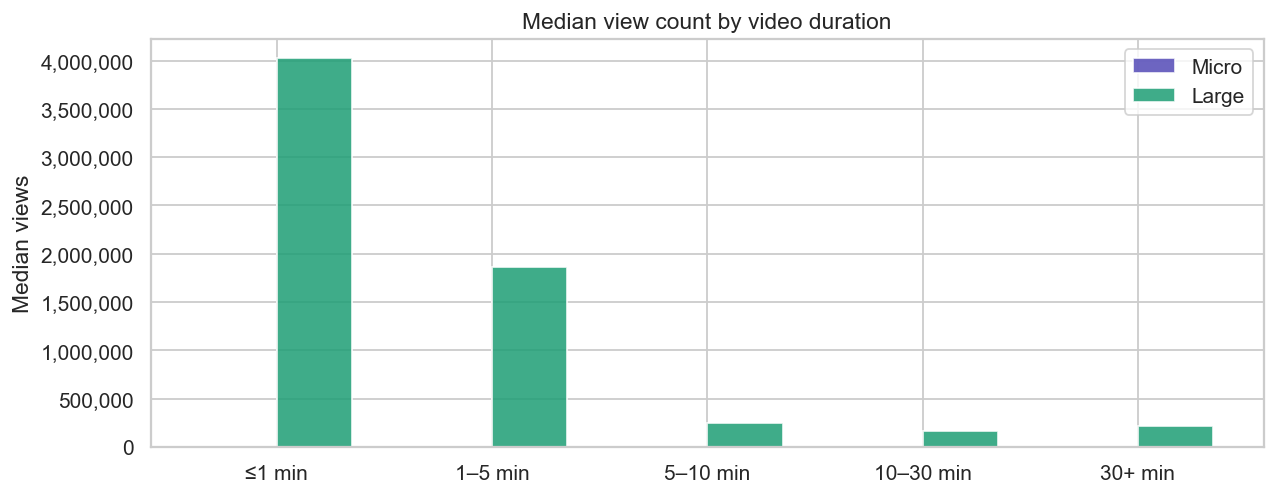

In [13]:
# Duration analysis
bins       = [0, 60, 300, 600, 1800, 99999]
dur_labels = ['≤1 min', '1–5 min', '5–10 min', '10–30 min', '30+ min']

micro['duration_bucket_std'] = pd.cut(micro['duration_sec'], bins=bins, labels=dur_labels)
large['duration_bucket_std'] = pd.cut(large['duration_sec'],  bins=bins, labels=dur_labels)

micro_dur = micro.groupby('duration_bucket_std', observed=True)['view_count'].median()
large_dur = large.groupby('duration_bucket_std', observed=True)['view_count'].median()

x = np.arange(len(dur_labels))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, micro_dur.reindex(dur_labels).values, width,
       label='Micro', color='#534AB7', alpha=0.85)
ax.bar(x + width/2, large_dur.reindex(dur_labels).values, width,
       label='Large', color='#1D9E75', alpha=0.85)
ax.set_title("Median view count by video duration")
ax.set_xticks(x)
ax.set_xticklabels(dur_labels)
ax.set_ylabel("Median views")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Golden Score calculation
# Step 1: micro median views per slot
micro_perf = micro.groupby(['post_day', 'publish_hour'])['view_count'].median().reset_index()
micro_perf.columns = ['day', 'hour', 'micro_median_views']

# Step 2: percentile rank
micro_perf['micro_rank'] = micro_perf['micro_median_views'].rank(pct=True)

# Step 3: large density per slot
large_density = large.groupby(['post_day', 'publish_hour']).size().reset_index()
large_density.columns = ['day', 'hour', 'large_video_count']
large_density['large_density_rank'] = large_density['large_video_count'].rank(pct=True)

# Step 4: Golden Score = micro_rank − large_density_rank
golden = pd.merge(micro_perf, large_density, on=['day', 'hour'], how='left')
golden['large_video_count']   = golden['large_video_count'].fillna(0)
golden['large_density_rank']  = golden['large_density_rank'].fillna(0)
golden['golden_score']        = golden['micro_rank'] - golden['large_density_rank']
golden = golden.sort_values('golden_score', ascending=False)

golden['day'] = pd.Categorical(golden['day'], categories=day_order, ordered=True)
top10 = golden.head(10).sort_values(['day', 'hour'])

print("TOP 10 GOLDEN POSTING WINDOWS")
print(top10[['day','hour','micro_median_views','large_video_count','golden_score']].to_string(index=False))

top10.to_csv("golden_windows.csv", index=False)

TOP 10 GOLDEN POSTING WINDOWS
     day  hour  micro_median_views  large_video_count  golden_score
  Monday     4              1261.0                2.0      0.683305
  Monday     6              1940.0                3.0      0.681768
  Monday     7              1191.0                2.0      0.601672
  Monday     9              1283.0                1.0      0.782026
  Monday    11              1294.0                3.0      0.620543
  Friday     5              5726.0                4.0      0.626199
  Friday    11              7233.5                4.0      0.636403
Saturday     9            143837.5                4.0      0.687423
  Sunday     0              4409.0                2.0      0.805754
  Sunday     7               957.0                0.0      0.642857


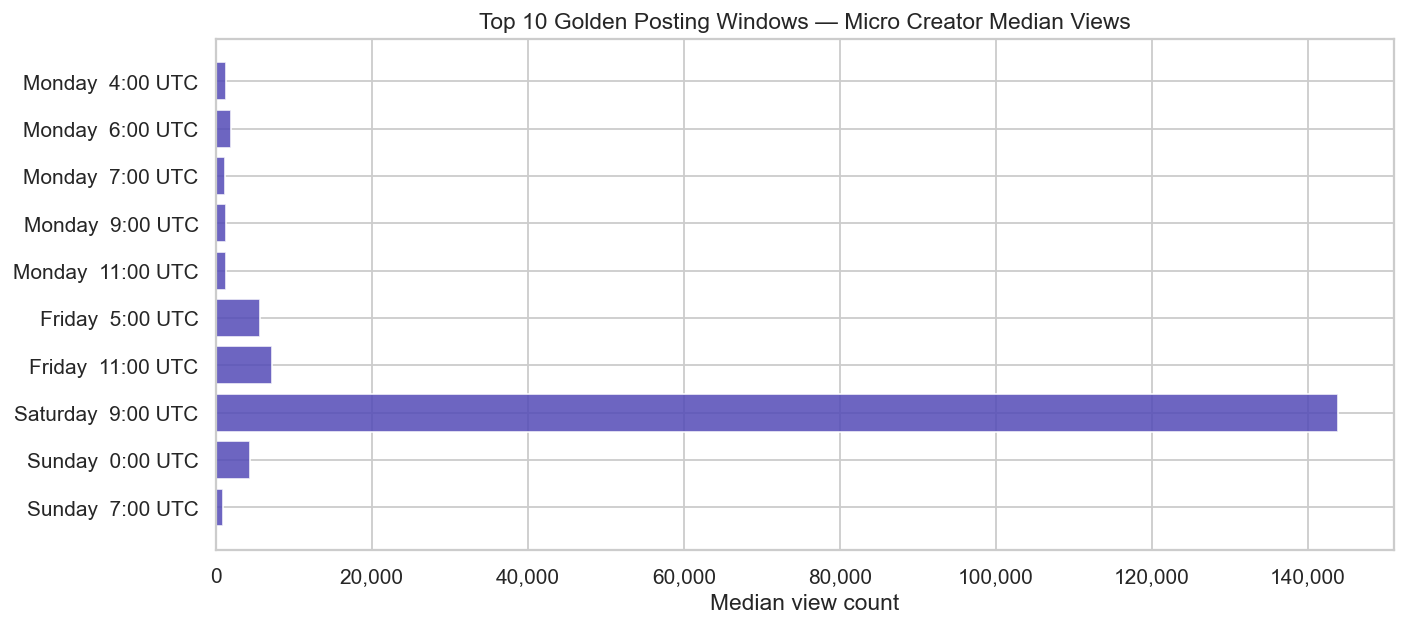

In [15]:
# Golden windows bar chart
top10['label'] = top10['day'].astype(str) + '  ' + top10['hour'].astype(str) + ':00 UTC'

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(top10['label'], top10['micro_median_views'], color='#534AB7', alpha=0.85)
ax.set_title("Top 10 Golden Posting Windows — Micro Creator Median Views")
ax.set_xlabel("Median view count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
# Summary
best_hour  = int(micro_hour.idxmax())
best_day   = micro_day.idxmax()
best_dur   = micro_dur.idxmax()
top_window = top10.iloc[0]

print("=" * 45)
print("  ACTIONABLE ROADMAP SUMMARY")
print("=" * 45)
print(f"  Best hour:     {best_hour}:00 UTC")
print(f"  Best day:      {best_day}")
print(f"  Best duration: {best_dur}")
print(f"  #1 Window:     {top_window['day']} at {int(top_window['hour'])}:00 UTC")
print(f"  Micro views:   {int(top_window['micro_median_views']):,}")
print(f"  Large posts:   {int(top_window['large_video_count'])}")
print("=" * 45)

  ACTIONABLE ROADMAP SUMMARY
  Best hour:     0:00 UTC
  Best day:      Friday
  Best duration: ≤1 min
  #1 Window:     Monday at 4:00 UTC
  Micro views:   1,261
  Large posts:   2


In [17]:
os.makedirs("content_golden_windows", exist_ok=True)

def get_large_density(large_subset=None):
    df = large if large_subset is None else large_subset
    density = df.groupby(['post_day', 'publish_hour']).size().reset_index()
    density.columns = ['day', 'hour', 'large_count']
    return density

def golden_windows_segment(micro_sub, large_sub=None, top_n=5):
    if len(micro_sub) < 10:
        return None
    perf = (micro_sub.groupby(['post_day', 'publish_hour'])['view_count']
                     .median().reset_index())
    perf.columns = ['day', 'hour', 'micro_median_views']
    perf['micro_rank'] = perf['micro_median_views'].rank(pct=True)
    density = get_large_density(large_sub)
    density['large_density_rank'] = density['large_count'].rank(pct=True)
    merged = pd.merge(perf, density, on=['day', 'hour'], how='left').fillna(0)
    merged['golden_score'] = merged['micro_rank'] - merged['large_density_rank']
    merged = merged.sort_values('golden_score', ascending=False)
    merged['day'] = pd.Categorical(merged['day'], categories=day_order, ordered=True)
    return merged.head(top_n)

def plot_segment_heatmap(df, title):
    if len(df) < 10:
        return
    pivot = (df.pivot_table(values='view_count', index='post_day',
                            columns='publish_hour', aggfunc='median')
               .reindex(day_order).reindex(columns=range(24), fill_value=0))
    fig, ax = plt.subplots(figsize=(16, 4))
    sns.heatmap(pivot, ax=ax, cmap='Purples', linewidths=0.3,
                cbar_kws={'label': 'Median views'})
    ax.set_title(title)
    ax.set_xlabel("Hour of day (UTC)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

print("Helpers defined.")

Helpers defined.



[Vlog] — 526 videos


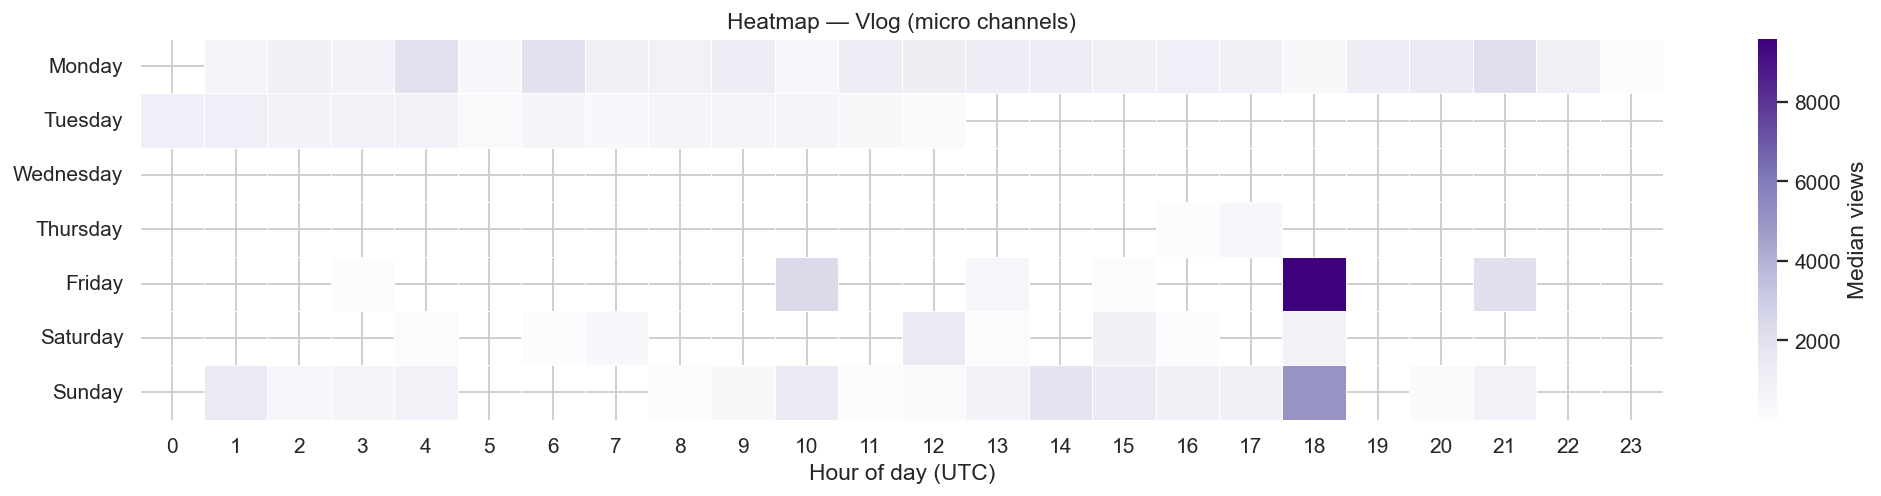

   day  hour  micro_median_views  large_count  golden_score
Monday     4              1933.0            2      0.810634
Monday     9              1259.0            1      0.758512
Monday     6              1940.0            3      0.731753
Monday    12              1160.5            2      0.636721
Monday    11              1294.0            3      0.615811

[Short] — 319 videos


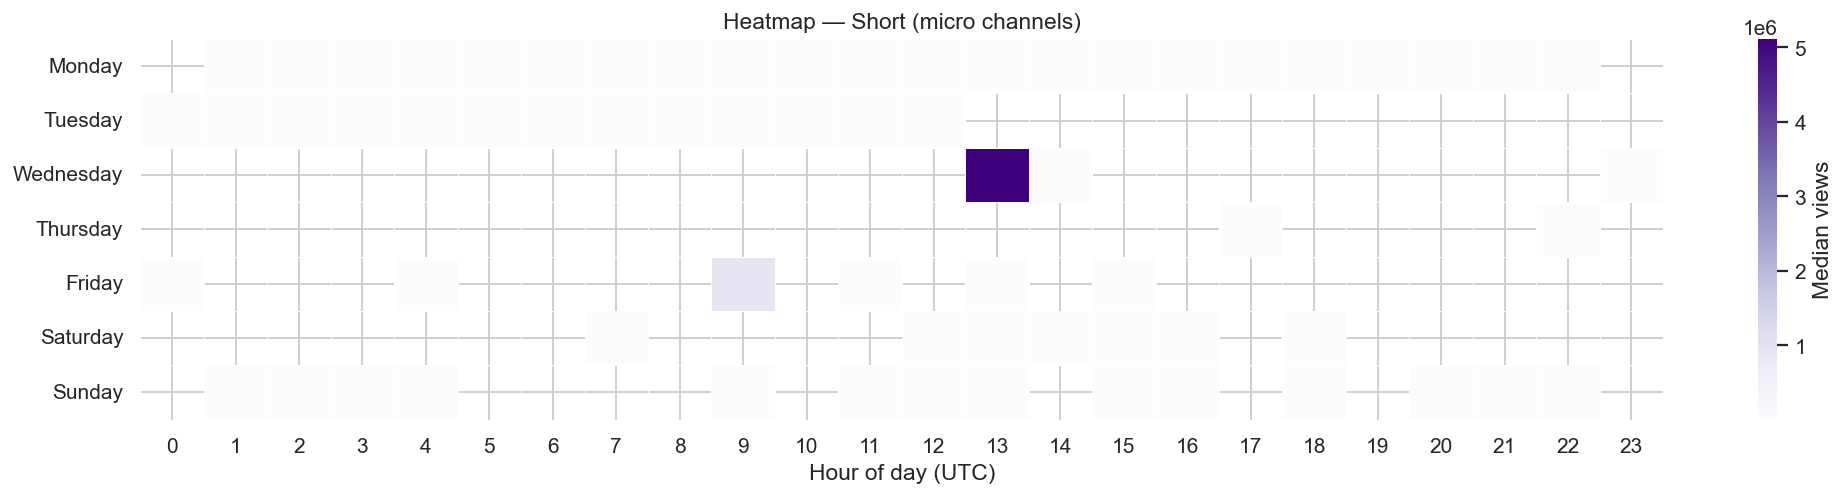

    day  hour  micro_median_views  large_count  golden_score
 Monday     4              1728.0            2      0.748337
 Monday     9              1357.5            1      0.737098
 Monday     6              1991.0            3      0.684814
Tuesday     6              1372.5            2      0.673710
 Friday    11              9983.0            4      0.648130

[Daily Life] — 219 videos


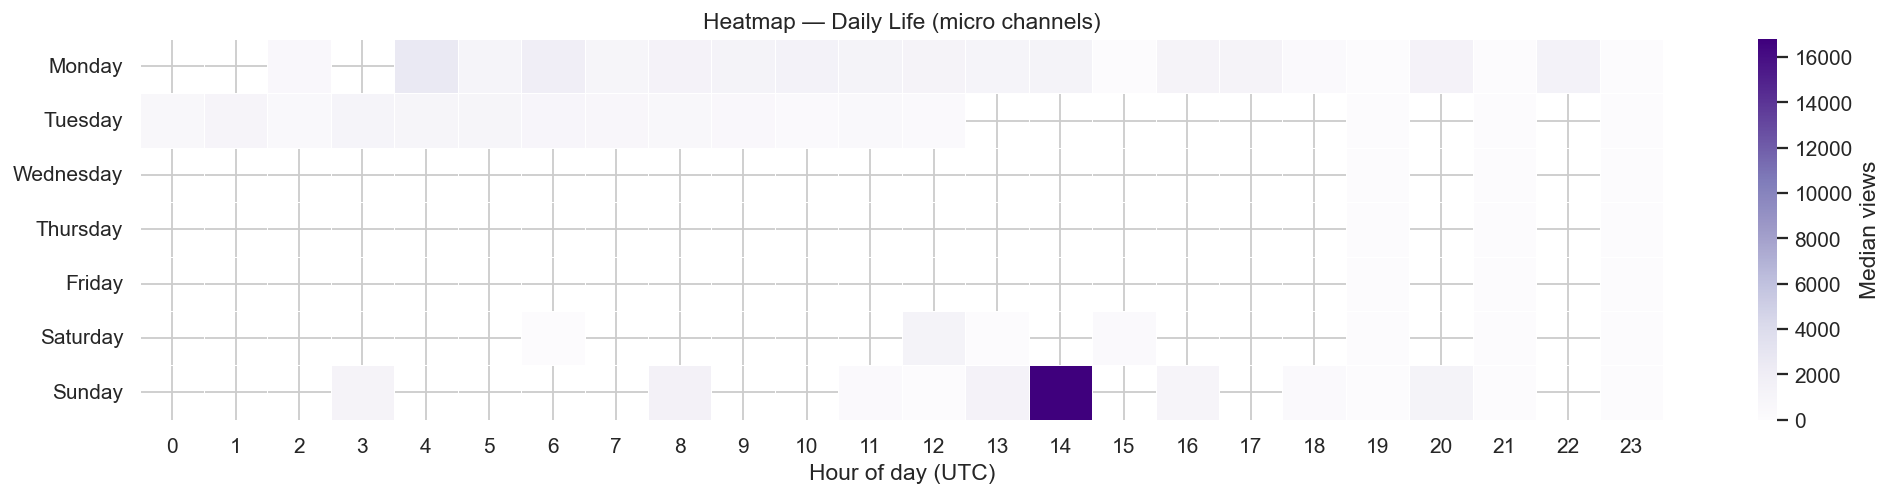

   day  hour  micro_median_views  large_count  golden_score
Monday     4              2605.0            2      0.874863
Sunday     8              1543.0            2      0.829409
Monday     6              1940.0            3      0.758762
Monday     9              1259.0            1      0.703176
Sunday    14             16782.0            5      0.599398

[Regular] — 353 videos


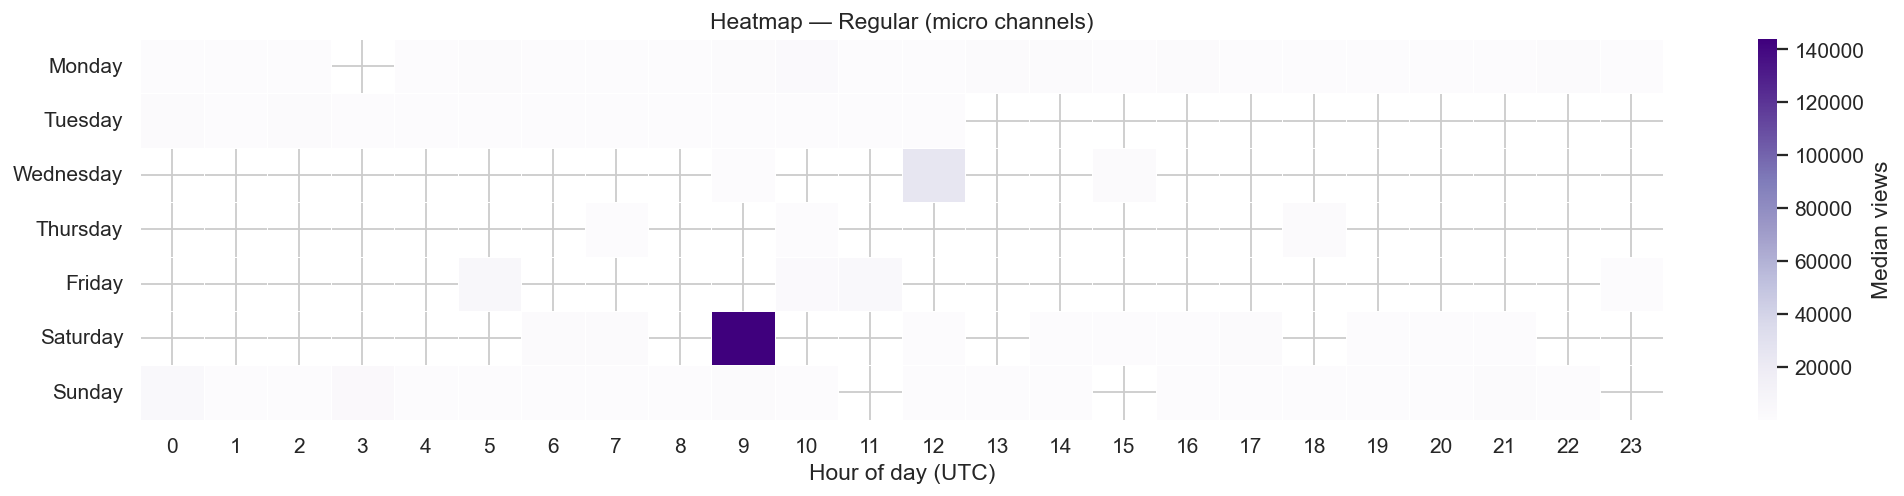

     day  hour  micro_median_views  large_count  golden_score
  Sunday     0              4409.0          2.0      0.846308
Saturday     7              1819.0          2.0      0.795026
  Monday     9              1403.0          1.0      0.783596
  Sunday     3              3700.0          3.0      0.740114
Saturday     9            143837.5          4.0      0.707831


In [18]:
# Dimension 1: Content Type
content_types = {
    'Vlog':       micro[micro['is_vlog'] == 1],
    'Short':      micro[micro['is_short'] == 1],
    'Daily Life': micro[micro['is_daily_life'] == 1],
    'Regular':    micro[(micro['is_vlog']==0)&(micro['is_short']==0)&(micro['is_daily_life']==0)],
}

all_d1 = []
for label, subset in content_types.items():
    print(f"\n[{label}] — {len(subset)} videos")
    plot_segment_heatmap(subset, f"Heatmap — {label} (micro channels)")
    w = golden_windows_segment(subset)
    if w is not None:
        print(w[['day','hour','micro_median_views','large_count','golden_score']].to_string(index=False))
        w.insert(0, 'content_type', label)
        all_d1.append(w)

if all_d1:
    pd.concat(all_d1).to_csv("content_golden_windows/golden_windows_by_content_type.csv", index=False)


[People & Blogs] — micro: 766 | large: 425


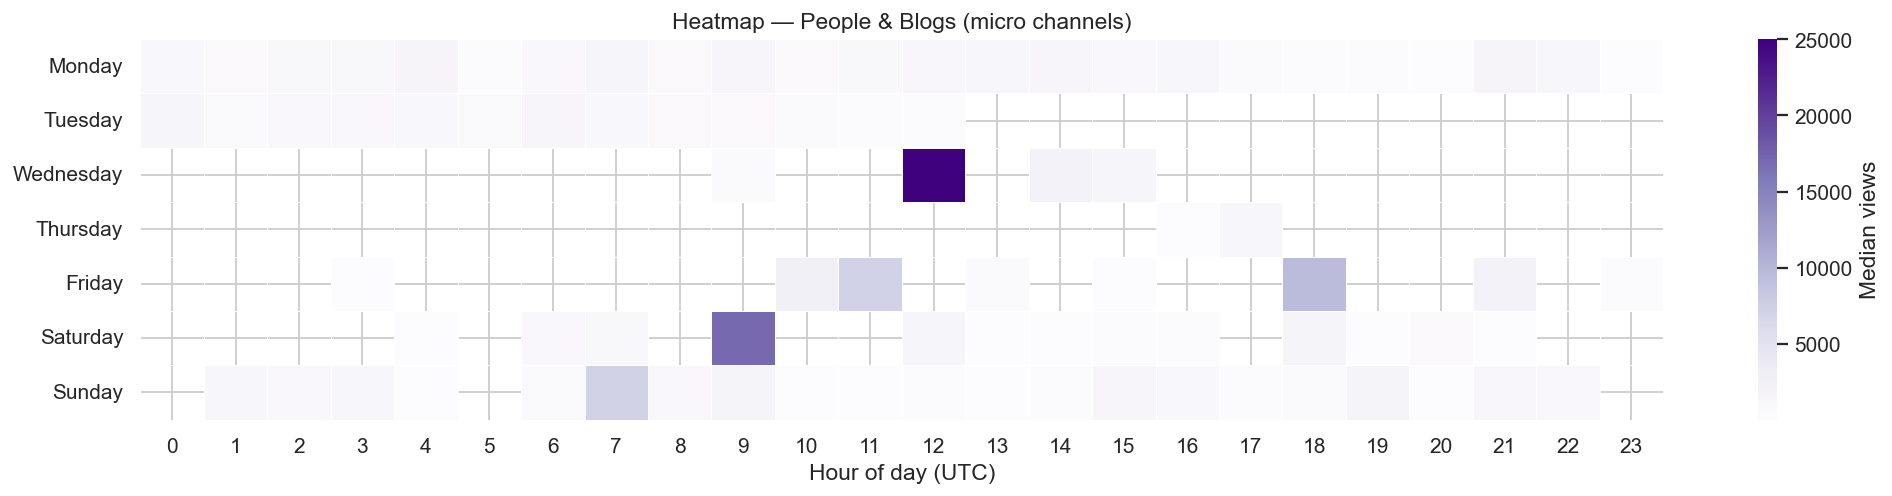

     day  hour  micro_median_views  large_count  golden_score
  Sunday     7              7096.0          0.0      0.952941
Saturday    18              1604.0          0.0      0.894118
  Friday    11              7233.5          1.0      0.854777
  Monday     7              1420.0          0.0      0.823529
  Sunday     9              1630.0          1.0      0.795953

[Entertainment] — micro: 82 | large: 209


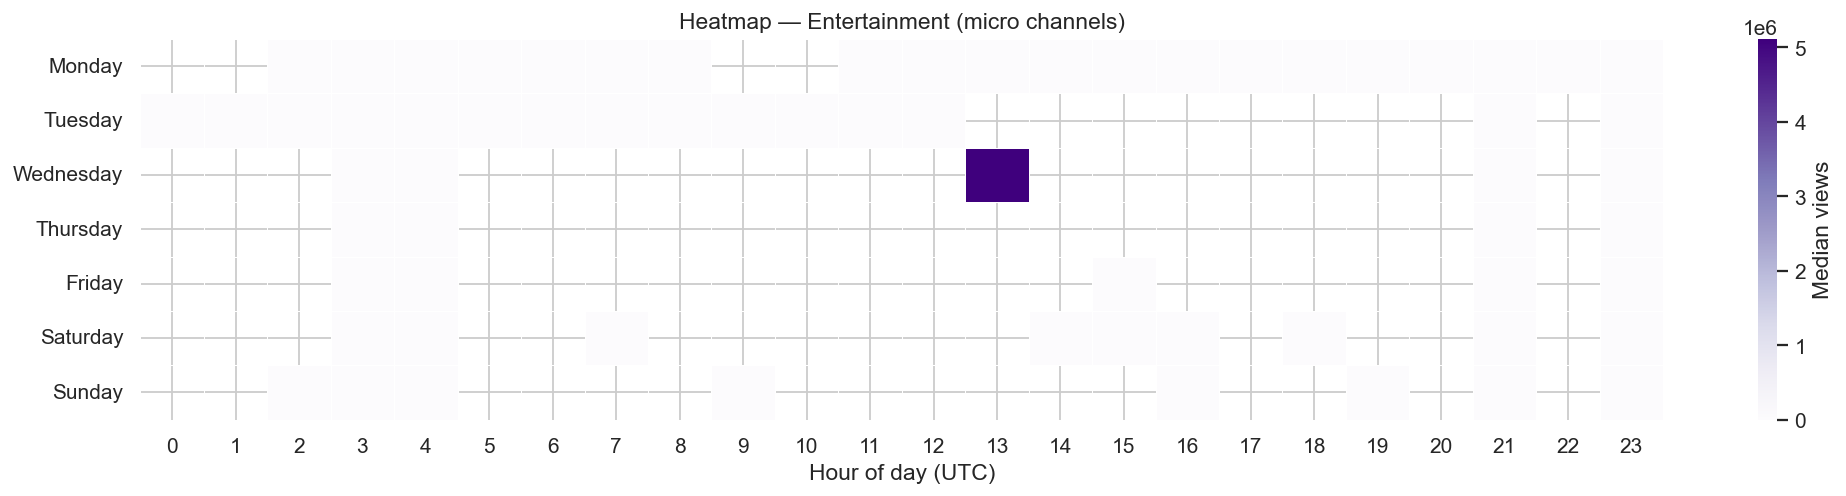

      day  hour  micro_median_views  large_count  golden_score
   Monday     8             20520.0          0.0      0.973684
   Monday     6              5445.5          0.0      0.921053
  Tuesday     0              1249.0          0.0      0.815789
   Monday    19              1211.5          0.0      0.763158
Wednesday    13           5112341.0          1.0      0.756881

[Gaming] — micro: 48 | large: 117


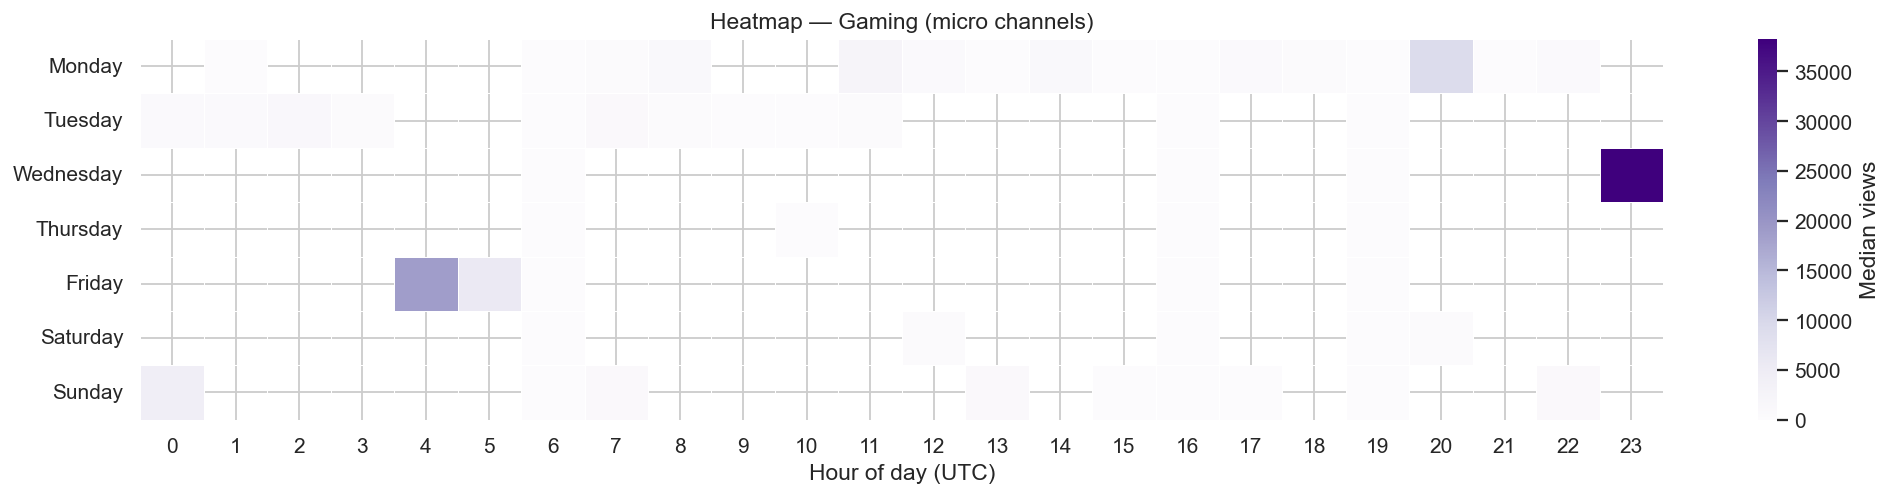

    day  hour  micro_median_views  large_count  golden_score
 Friday     4             18734.0          0.0      0.970588
 Monday    20              9003.0          0.0      0.941176
 Sunday     0              4409.0          0.0      0.882353
 Monday    11              2287.0          0.0      0.852941
Tuesday     2              1310.0          0.0      0.823529

[Education] — micro: 45 | large: 17


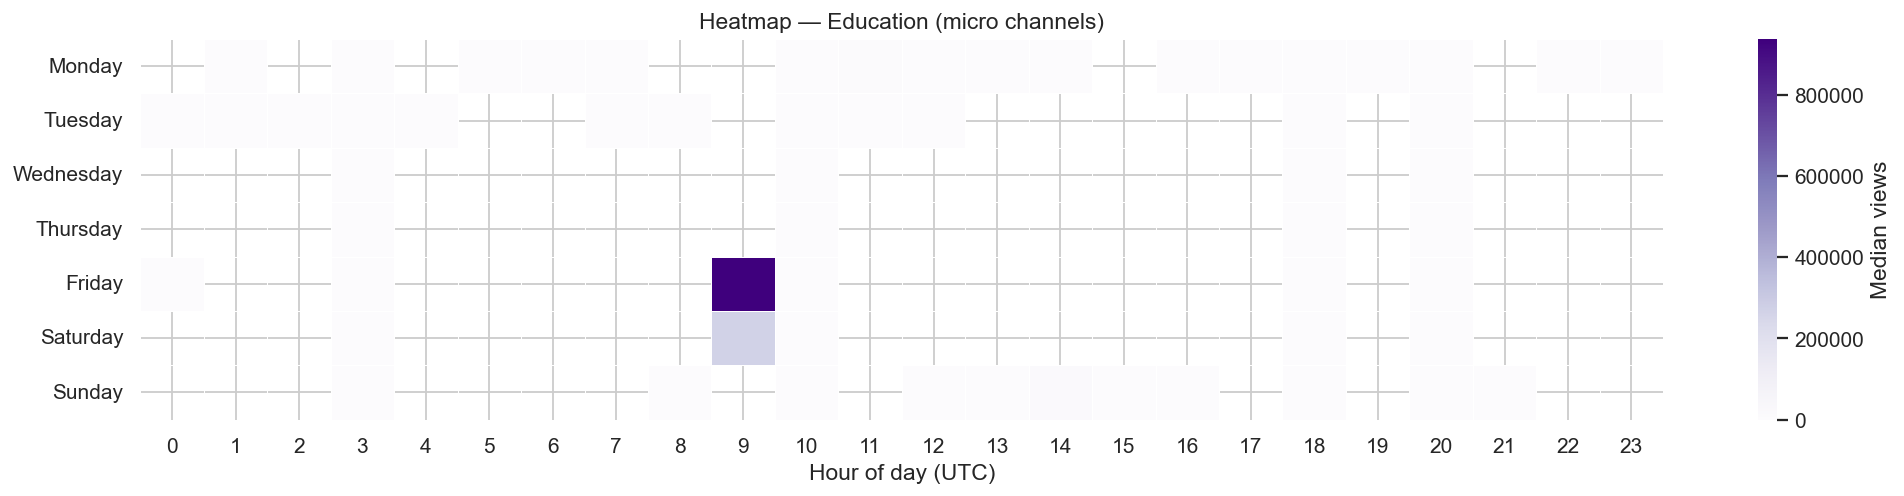

     day  hour  micro_median_views  large_count  golden_score
  Friday     9            936582.0          0.0      1.000000
Saturday     9            270606.0          0.0      0.967742
  Sunday    14             16782.0          0.0      0.935484
  Monday    11              7822.0          0.0      0.903226
  Monday    22              3598.0          0.0      0.870968

[Howto & Style] — micro: 24 | large: 20


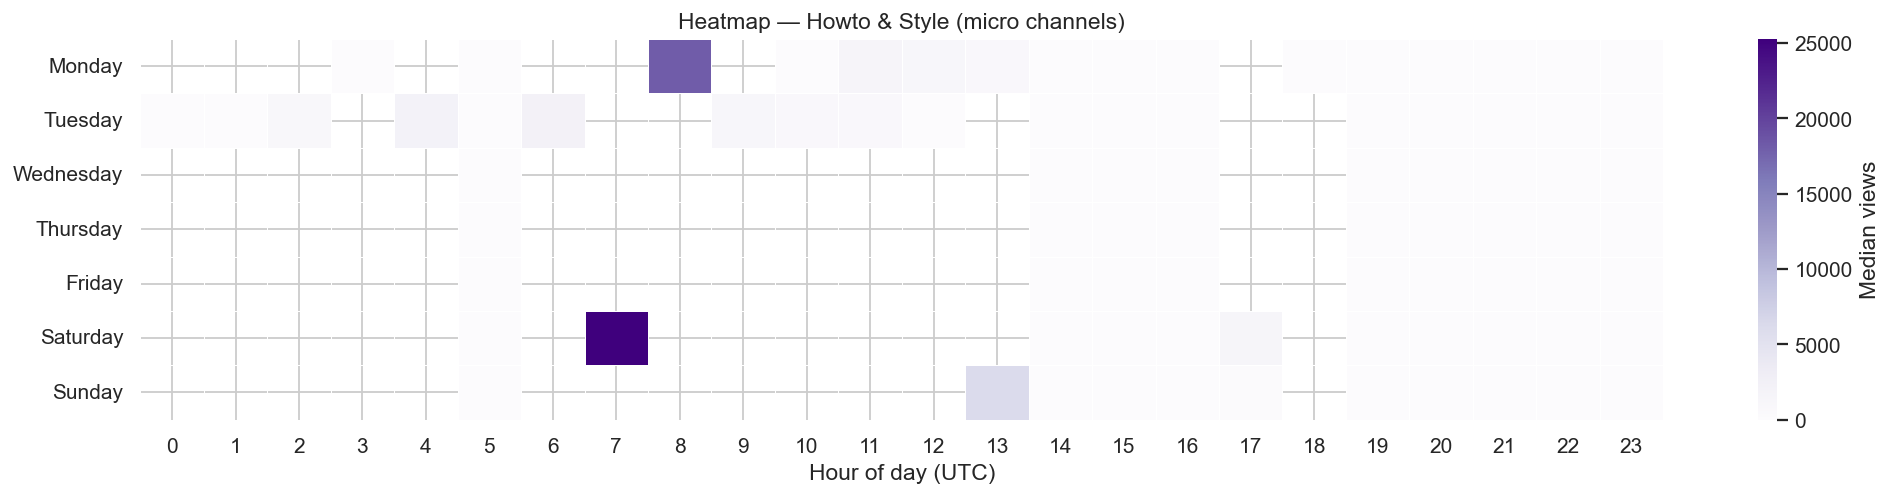

     day  hour  micro_median_views  large_count  golden_score
Saturday     7             25260.0          0.0          1.00
  Monday     8             18061.0          0.0          0.95
 Tuesday     6              2268.0          0.0          0.85
 Tuesday     4              2164.0          0.0          0.80
  Monday    11              1484.0          0.0          0.75


In [19]:
# Dimension 2: Category (top 5)
top_cats = micro['category_name'].value_counts().head(5).index.tolist()
all_d2 = []

for cat in top_cats:
    micro_cat = micro[micro['category_name'] == cat]
    large_cat = large[large['category_name'] == cat]
    print(f"\n[{cat}] — micro: {len(micro_cat)} | large: {len(large_cat)}")
    plot_segment_heatmap(micro_cat, f"Heatmap — {cat} (micro channels)")
    w = golden_windows_segment(micro_cat, large_cat if len(large_cat) > 5 else None)
    if w is not None:
        print(w[['day','hour','micro_median_views','large_count','golden_score']].to_string(index=False))
        w.insert(0, 'category', cat)
        all_d2.append(w)

if all_d2:
    pd.concat(all_d2).to_csv("content_golden_windows/golden_windows_by_category.csv", index=False)


[Short (≤1 min)] — micro: 789 | large: 720


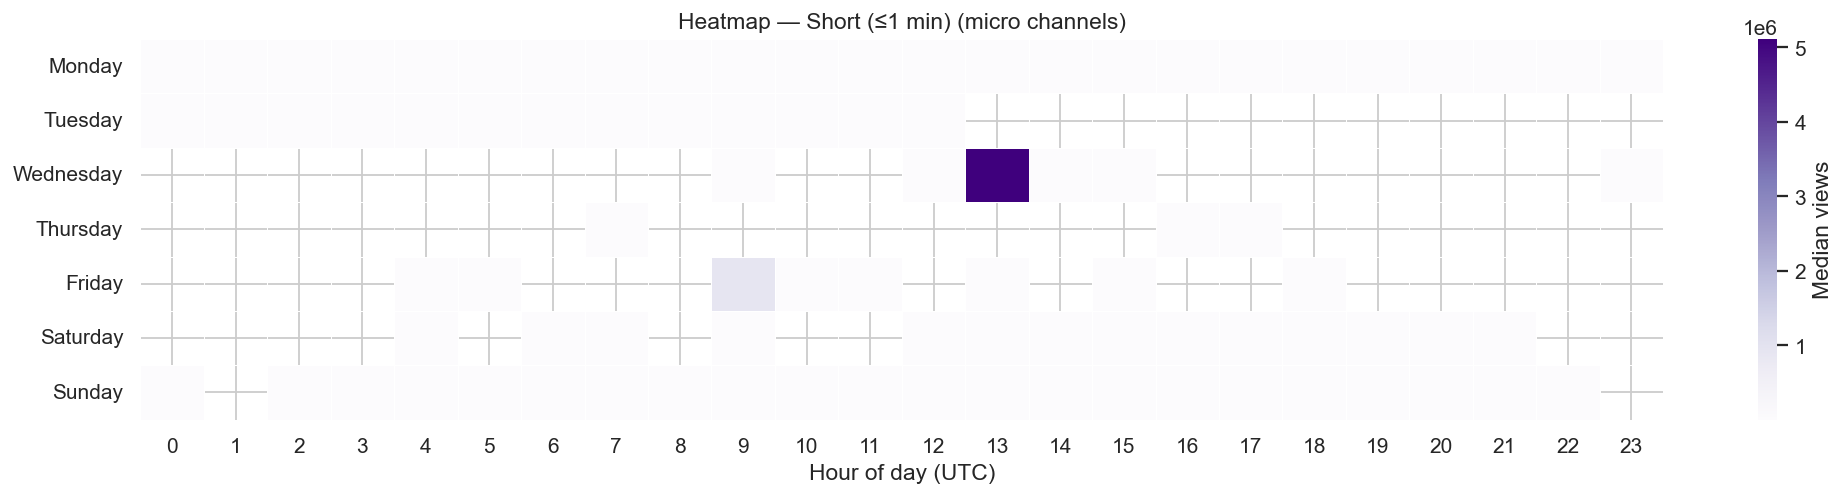

     day  hour  micro_median_views  large_count  golden_score
  Friday     4             18734.0          1.0      0.884568
Saturday     9             17069.0          1.0      0.873457
  Friday     5              5726.0          1.0      0.851235
  Monday     6              1991.0          1.0      0.806790
 Tuesday     6              1372.5          1.0      0.740123

[Mid (1–10 min)] — micro: 169 | large: 239


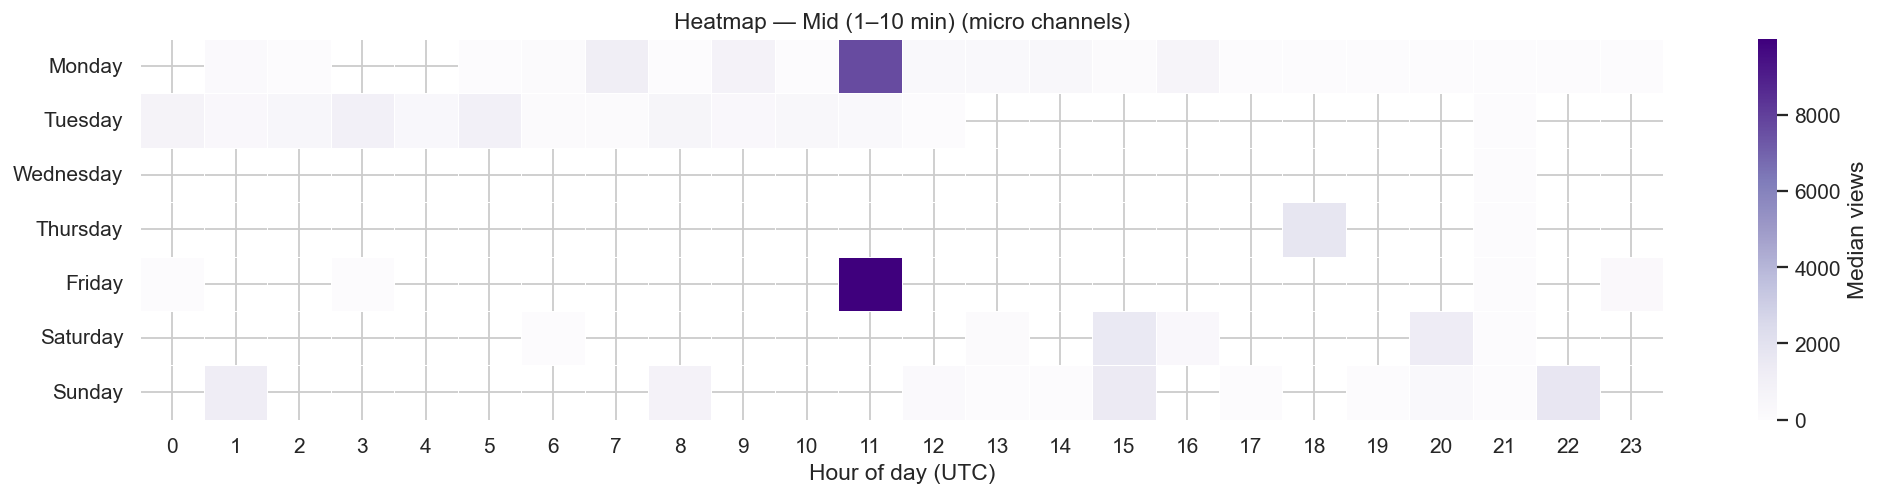

     day  hour  micro_median_views  large_count  golden_score
  Friday    11              9983.0          0.0      1.000000
  Monday    11              7680.0          0.0      0.981132
  Sunday    15              1467.0          0.0      0.905660
Saturday    20              1294.0          0.0      0.886792
  Sunday     1              1238.0          0.0      0.867925

[Long (10+ min)] — micro: 77 | large: 218


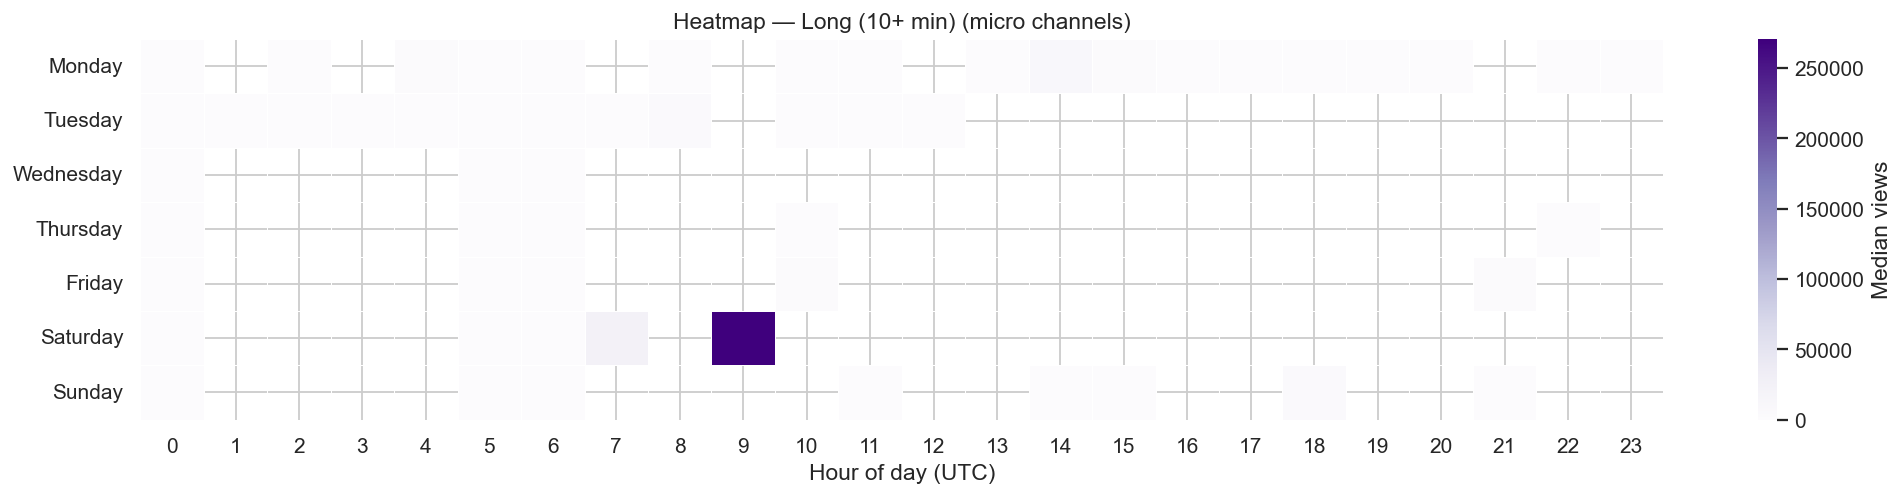

     day  hour  micro_median_views  large_count  golden_score
  Monday    14              9750.5          0.0      0.942857
 Tuesday     8              5696.5          0.0      0.914286
  Monday     4              2605.0          0.0      0.857143
  Friday    10              2410.0          0.0      0.828571
Saturday     9            270606.0          1.0      0.772727


In [20]:
# Dimension 3: Video Length
bins_dur   = [0, 60, 600, 99999]
labels_dur = ['Short (≤1 min)', 'Mid (1–10 min)', 'Long (10+ min)']

micro['dur_group'] = pd.cut(micro['duration_sec'], bins=bins_dur, labels=labels_dur)
large['dur_group'] = pd.cut(large['duration_sec'],  bins=bins_dur, labels=labels_dur)

all_d3 = []
for dur in labels_dur:
    ms = micro[micro['dur_group'] == dur]
    ls = large[large['dur_group'] == dur]
    print(f"\n[{dur}] — micro: {len(ms)} | large: {len(ls)}")
    plot_segment_heatmap(ms, f"Heatmap — {dur} (micro channels)")
    w = golden_windows_segment(ms, ls if len(ls) > 5 else None)
    if w is not None:
        print(w[['day','hour','micro_median_views','large_count','golden_score']].to_string(index=False))
        w.insert(0, 'duration_group', dur)
        all_d3.append(w)

if all_d3:
    pd.concat(all_d3).to_csv("content_golden_windows/golden_windows_by_duration.csv", index=False)


[First video (brand new)] — 160 videos


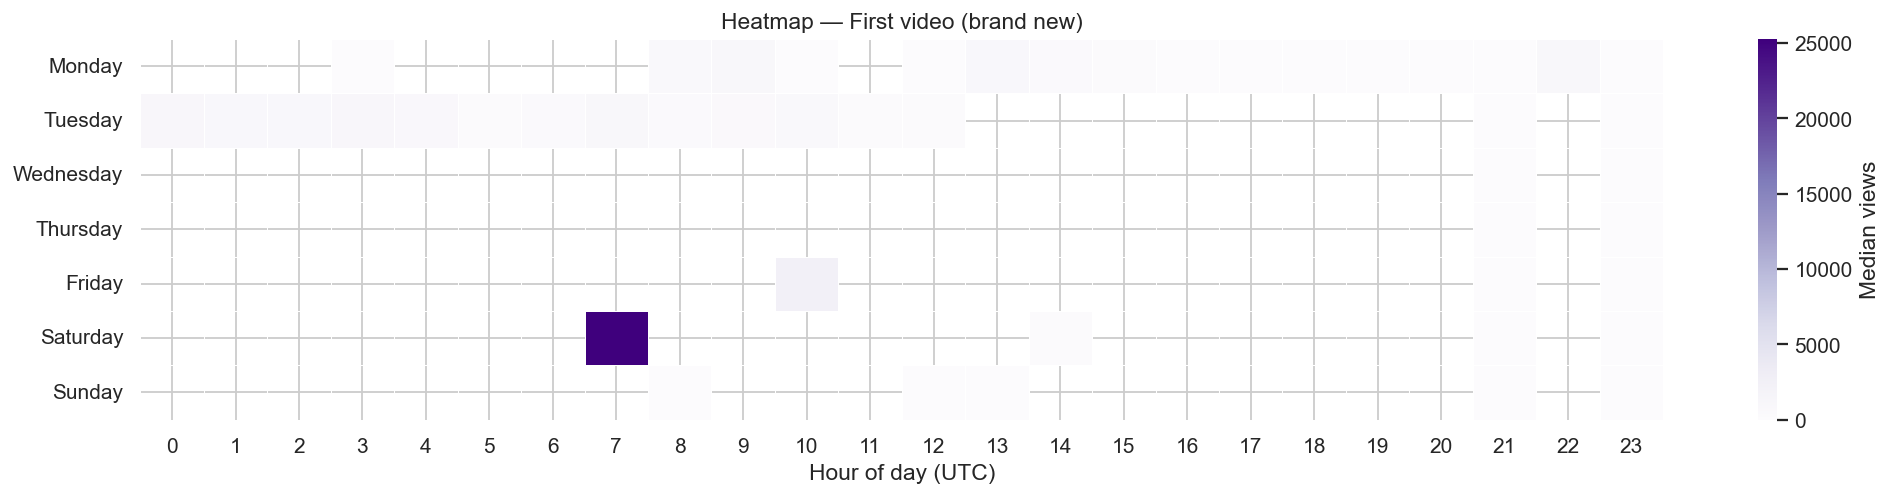

     day  hour  micro_median_views  large_count  golden_score
Saturday     7             25260.0            2      0.897590
  Monday     9              1059.0            1      0.854691
 Tuesday     7              1038.5            2      0.715772
  Friday    10              2410.0            5      0.569095
 Tuesday     6               552.0            2      0.473348

[Established micro] — 875 videos


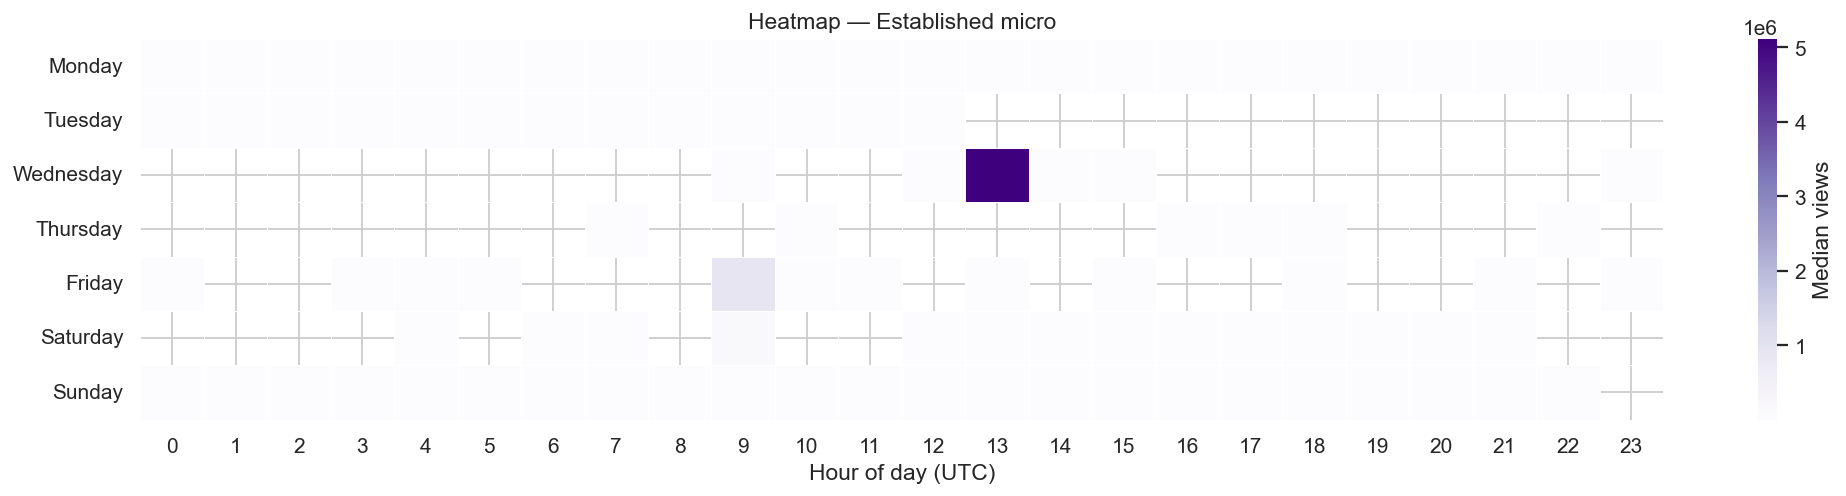

     day  hour  micro_median_views  large_count  golden_score
  Sunday     0              4409.0          2.0      0.805754
  Monday     9              1307.0          1.0      0.782026
Saturday     9            143837.5          4.0      0.687423
  Monday     6              1940.0          3.0      0.681768
  Monday     4              1261.0          2.0      0.662896


In [21]:
# Dimension 4: Channel Stage
channel_types = {
    'First video (brand new)': micro[micro['is_first_video'] == 1],
    'Established micro':       micro[micro['is_first_video'] == 0],
}

all_d4 = []
for label, subset in channel_types.items():
    print(f"\n[{label}] — {len(subset)} videos")
    plot_segment_heatmap(subset, f"Heatmap — {label}")
    w = golden_windows_segment(subset)
    if w is not None:
        print(w[['day','hour','micro_median_views','large_count','golden_score']].to_string(index=False))
        w.insert(0, 'channel_type', label)
        all_d4.append(w)

if all_d4:
    pd.concat(all_d4).to_csv("content_golden_windows/golden_windows_by_channel_type.csv", index=False)

In [ ]:
# Bonus: 2×2 comparison heatmap
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()

plot_configs = [
    ('Vlog',       micro[micro['is_vlog'] == 1]),
    ('Short',      micro[micro['is_short'] == 1]),
    ('Daily Life', micro[micro['is_daily_life'] == 1]),
    ('Regular',    micro[(micro['is_vlog']==0)&(micro['is_short']==0)&(micro['is_daily_life']==0)]),
]

for ax, (label, subset) in zip(axes, plot_configs):
    pivot = (subset.pivot_table(values='view_count', index='post_day',
                                columns='publish_hour', aggfunc='median')
                   .reindex(day_order).reindex(columns=range(24), fill_value=0))
    sns.heatmap(pivot, ax=ax, cmap='Purples', linewidths=0.2,
                cbar_kws={'label': 'Median views'}, xticklabels=2)
    ax.set_title(f"{label}  (n={len(subset)})", fontsize=12)
    ax.set_xlabel("Hour (UTC)")
    ax.set_ylabel("")

fig.suptitle("Golden Posting Windows by Content Type — Micro Channels", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("content_golden_windows/comparison_all_content_types.png", bbox_inches='tight')
plt.show()